# Hyperbolic World Model — Experiment 1
## Does the Busemann coordinate $\tau_t$ spontaneously encode hierarchical depth?

---

### What this notebook does

We train a sequential world model whose latent space is **hyperbolic space** $\mathbb{H}^d$, and ask whether the geometric coordinate $\tau_t$ (the Busemann coordinate, measuring depth in $\mathbb{H}^d$) spontaneously aligns with the true hierarchical depth of the environment — **without any explicit supervision on depth**.

The environment is a $B$-ary tree MDP where each node has a known depth $\ell \in \{0, \ldots, L\}$. The model only sees observations $o_t \in \mathbb{R}^{d_{\mathrm{obs}}}$ and actions. After training, we measure:

$$\rho_\tau = \mathrm{Spearman}(\mu_\tau^q(v),\; \ell(v))$$

and compare against an identical Euclidean baseline on $\mathbb{R}^d$.

### Latent space design

The latent space is **purely hyperbolic**: $z_t = (\tau_t, b_t) \in \mathbb{H}^{d_2}$.
- $\tau_t \in \mathbb{R}$ — Busemann coordinate (depth direction)
- $b_t \in \mathbb{R}^{d_2 - 1}$ — fibre coordinate (lateral position within a level)

There is no separate Euclidean working memory component (`d1 = 0`). This makes the comparison clean: **$\mathbb{H}^{d_2}$ vs $\mathbb{R}^{d_2}$, same total dimensions, same decoder.**

### How to run

On **Google Colab**: `Runtime → Change runtime type → T4 GPU`, then `Runtime → Run all`.

Expected time: ~12 min per condition on T4 GPU, ~60 min on CPU.

---

In [1]:
# Install dependencies (only needed on Colab / fresh environment)
!pip install pytorch-lightning scipy scikit-learn matplotlib seaborn umap-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 29.4 MB/s eta 0:00:00


In [2]:
import os, json, random, math, time, csv
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger

from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
Memory : 15.6 GB


---
## Part 1 — Environment: $B$-ary Tree MDP

### Design

We build a rooted $B$-ary tree of depth $L$. Each node $v$ has:
- A known ground-truth depth $\ell(v) \in \{0, \ldots, L\}$
- A fixed observation generated by mixing two random embeddings:
  - $e_v^{\mathrm{depth}} \in \mathbb{R}^{d_{\mathrm{obs}}/2}$ — encodes the depth level
  - $e_v^{\mathrm{branch}} \in \mathbb{R}^{d_{\mathrm{obs}}/2}$ — encodes the branch identity

$$o_v = \tanh\left(W_{\mathrm{obs}} \cdot \mathrm{concat}(e_v^{\mathrm{depth}}, e_v^{\mathrm{branch}})\right) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma_{\mathrm{obs}}^2 I)$$

**The model never sees $e_v^{\mathrm{depth}}$, $e_v^{\mathrm{branch}}$, or the depth label.** It only sees $o_v$ and must discover the structure from sequential prediction.

### Actions
- Action `0` → go to parent (stay at root if already root)
- Actions `1..B` → go to child $i$

Trajectories are random walks biased toward descent (`p_down = 0.7`) so the model sees many depth transitions.

In [3]:
@dataclass
class TreeNode:
    node_id : int
    depth   : int
    branch  : Tuple         # sequence of child indices from root to this node
    parent  : Optional[int] # None for root
    children: List[int] = field(default_factory=list)


class BaryTree:
    """
    B-ary tree MDP of depth L.

    Observations are generated from fixed random embeddings that the model
    never sees directly. The only input to the model is o_v and actions.
    """

    def __init__(self, B, L, obs_dim, obs_noise=0.1, seed=42):
        self.B, self.L   = B, L
        self.obs_dim     = obs_dim
        self.obs_noise   = obs_noise
        self.n_actions   = B + 1  # 0=up, 1..B=child i
        rng = np.random.default_rng(seed)

        # ── Build tree (BFS) ─────────────────────────────────────────────
        self.nodes: List[TreeNode] = []
        queue = [(0, 0, None, ())]
        while queue:
            nid, depth, parent, branch = queue.pop(0)
            node = TreeNode(nid, depth, branch, parent)
            self.nodes.append(node)
            if depth < L:
                for c in range(B):
                    cid = len(self.nodes) + len(queue)
                    node.children.append(cid)
                    queue.append((cid, depth+1, nid, branch+(c,)))

        # ── Fixed observation parameters (never given to model) ───────────
        half = obs_dim // 2
        self.depth_emb  = rng.standard_normal((L+1,          half)).astype(np.float32)
        self.branch_emb = rng.standard_normal((len(self.nodes), half)).astype(np.float32)

        # Fixed random projection matrix (row-normalised)
        W = rng.standard_normal((obs_dim, obs_dim)).astype(np.float32)
        self.obs_W = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-8)

        print(f'Tree: B={B}, L={L}, total nodes={self.n_nodes()}, leaves={B**L}')

    def n_nodes(self):
        return len(self.nodes)

    def observation(self, node_id, noise=True):
        """Generate o_v from depth + branch embeddings."""
        node = self.nodes[node_id]
        raw  = np.concatenate([self.depth_emb[node.depth],
                               self.branch_emb[node_id]])
        obs  = np.tanh(self.obs_W @ raw)
        if noise:
            obs = obs + np.random.randn(self.obs_dim).astype(np.float32) * self.obs_noise
        return obs.astype(np.float32)

    def step(self, node_id, action):
        """Deterministic transition."""
        node = self.nodes[node_id]
        if action == 0:
            return node.parent if node.parent is not None else node_id
        c = action - 1
        return node.children[c] if c < len(node.children) else node_id

    def random_walk(self, start_id, length, p_down=0.7):
        """Generate a random trajectory of given length."""
        node_ids, actions = [start_id], []
        curr = start_id
        for _ in range(length - 1):
            node = self.nodes[curr]
            if node.depth == self.L:
                action = 0
            elif node.depth == 0:
                action = random.randint(1, self.B)
            else:
                action = random.randint(1, self.B) if random.random() < p_down else 0
            curr = self.step(curr, action)
            node_ids.append(curr)
            actions.append(action)
        actions.append(0)  # dummy terminal action
        return node_ids, actions


class TreeDataset(Dataset):
    """
    Pre-generates N trajectories of length T.

    Each item: { obs (T, obs_dim), actions (T,), depths (T,), node_ids (T,) }
    depths and node_ids are ground truth — used only for evaluation, not training.
    """
    def __init__(self, tree, n_traj, seq_len, p_down=0.7, seed=0):
        random.seed(seed)
        np.random.seed(seed)
        self.data = []
        for _ in range(n_traj):
            start    = random.randint(0, tree.n_nodes()-1)
            ids, acts = tree.random_walk(start, seq_len, p_down)
            obs      = np.stack([tree.observation(i) for i in ids])
            self.data.append({
                'obs':      torch.from_numpy(obs),
                'actions':  torch.tensor(acts,   dtype=torch.long),
                'depths':   torch.tensor([tree.nodes[i].depth for i in ids], dtype=torch.long),
                'node_ids': torch.tensor(ids,    dtype=torch.long),
            })

    def __len__(self):         return len(self.data)
    def __getitem__(self, i):  return self.data[i]


# Quick sanity check
_t = BaryTree(B=3, L=3, obs_dim=32)
_ids, _ = _t.random_walk(0, 10)
print('Sample walk depths:', [_t.nodes[i].depth for i in _ids])

Tree: B=3, L=3, total nodes=40, leaves=27
Sample walk depths: [0, 1, 0, 1, 2, 1, 2, 1, 2, 3]


---
## Part 2 — The Horospherical Gaussian $\mathcal{HG}$

### Why a new distribution?

The natural distribution on $\mathbb{H}^d$ is the Riemannian Normal $\mathcal{N}_\mathbb{H}(\mu, \sigma^2) \propto e^{-d_\mathbb{H}^2(z,\mu)/2\sigma^2}$. The problem: its normalising constant involves $\int_0^\infty e^{-r^2/2\sigma^2} \sinh^{d-1}(r) dr$, which has no closed form for $d \geq 3$. KL divergences require Monte Carlo — too slow for RSSM training.

### The key idea

In the upper half-space model $\mathbb{H}^d = \{(\tau, b) : \tau \in \mathbb{R}, b \in \mathbb{R}^{d-1}\}$, the Riemannian volume form is $d\mathrm{vol} = e^{-(d-1)\tau} d\tau\, db$. The factor $e^{-(d-1)\tau}$ is what makes integrals hard.

We choose the conditional variance $\mathrm{Var}(b|\tau) = e^{2\tau}\sigma_b^2$. Then:

$$\int_{\mathbb{R}^{d-1}} e^{-\|b-\mu_b\|^2/2e^{2\tau}\sigma_b^2}\, db = (2\pi\sigma_b^2)^{(d-1)/2} \cdot e^{(d-1)\tau}$$

The $e^{(d-1)\tau}$ from the integral **cancels exactly** with $e^{-(d-1)\tau}$ from the volume form. The normalising constant becomes independent of $\mu_\tau$ — making the KL divergence tractable.

### Definition

$$\mathcal{HG}(\mu_\tau, \mu_b, \sigma_\tau, \sigma_b):\quad \tilde{p}(\tau, b) = \exp\!\left(-\frac{(\tau-\mu_\tau)^2}{2\sigma_\tau^2} - \frac{\|b-\mu_b\|^2}{2e^{2\tau}\sigma_b^2}\right)$$

### KL divergence — closed form

For $q = \mathcal{HG}(\mu_\tau^q, \mu_b^q, \sigma_\tau^q, \sigma_b^q)$ and $p = \mathcal{HG}(\mu_\tau^p, \mu_b^p, \sigma_\tau^p, \sigma_b^p)$:

$$\mathrm{KL}[q\|p] = \underbrace{\log\frac{\sigma_\tau^p}{\sigma_\tau^q} + \frac{(\sigma_\tau^q)^2 + (\mu_\tau^q-\mu_\tau^p)^2}{2(\sigma_\tau^p)^2} - \frac{1}{2}}_{\text{height KL}} + (d-1)\underbrace{\left(\log\frac{\sigma_b^p}{\sigma_b^q} + \frac{(\sigma_b^q)^2}{2(\sigma_b^p)^2} - \frac{1}{2}\right)}_{\text{fibre KL}} + \underbrace{\frac{\|\mu_b^q-\mu_b^p\|^2}{2(\sigma_b^p)^2}\,e^{-2\mu_\tau^q+2(\sigma_\tau^q)^2}}_{\text{drift term}}$$

All three terms are closed form. Total cost: $O(d)$.

### Reparameterisation

$$\tau = \mu_\tau^q + \sigma_\tau^q\,\varepsilon_1, \qquad b = \mu_b^q + e^\tau\,\sigma_b^q\,\varepsilon_2$$

**Important:** $b$ depends on $\mu_\tau^q$ through $e^\tau$. Autograd handles this correctly via the computation graph — but only if $\tau$ is computed before $b$.

In [4]:
class HGDist:
    """
    Horospherical Gaussian HG(mu_tau, mu_b, sigma_tau, sigma_b) on H^d.

    Parameterised in log-space for numerical stability:
      sigma_tau = exp(log_sig_tau),  sigma_b = exp(log_sig_b)
    """

    def __init__(self, mu_tau, mu_b, log_sig_tau, log_sig_b):
        self.mu_tau      = mu_tau        # (...,)
        self.mu_b        = mu_b          # (..., d-1)
        self.log_sig_tau = log_sig_tau   # (...,)
        self.log_sig_b   = log_sig_b     # (...,)
        self.sig_tau     = torch.exp(log_sig_tau)
        self.sig_b       = torch.exp(log_sig_b)

    # ── Sampling ──────────────────────────────────────────────────────────

    def rsample(self):
        """
        Exact reparameterised sample.

          tau = mu_tau + sig_tau * eps1          [standard Gaussian in tau]
          b   = mu_b   + exp(tau) * sig_b * eps2 [Gaussian with e^{2tau} variance]

        The coupling b <-> mu_tau through exp(tau) is handled by autograd.
        """
        eps1 = torch.randn_like(self.mu_tau)   # (...,)
        eps2 = torch.randn_like(self.mu_b)     # (..., d-1)
        tau  = self.mu_tau + self.sig_tau * eps1
        b    = self.mu_b   + torch.exp(tau).unsqueeze(-1) * self.sig_b.unsqueeze(-1) * eps2
        return tau, b

    # ── KL divergence — closed form ────────────────────────────────────────

    @staticmethod
    def kl(q: 'HGDist', p: 'HGDist') -> Tensor:
        """
        KL(q || p) in closed form.

        Three terms (each O(1) to compute, total O(d)):

        1. height_kl : KL between the tau marginals
             = log(sig_p/sig_q) + (sig_q^2 + (mu_q-mu_p)^2) / (2 sig_p^2) - 1/2

        2. fibre_kl  : (d-1) * KL between fibre scale distributions
             = (d-1) * [log(sig_b_p/sig_b_q) + sig_b_q^2/(2 sig_b_p^2) - 1/2]

        3. drift     : cross-mean term via MGF of Gaussian at s=-2
             = ||mu_b_q - mu_b_p||^2 / (2 sig_b_p^2) * exp(-2 mu_tau_q + 2 sig_tau_q^2)
             where E[e^{-2tau}] = exp(-2 mu_tau_q + 2 sig_tau_q^2)  [MGF]
        """
        d_minus_1 = q.mu_b.shape[-1]   # = d - 1

        # 1. Height KL (standard 1D Gaussian KL formula)
        height = (p.log_sig_tau - q.log_sig_tau
                  + (q.sig_tau**2 + (q.mu_tau - p.mu_tau)**2) / (2 * p.sig_tau**2)
                  - 0.5)

        # 2. Fibre scale KL (isotropic, identical across d-1 dimensions)
        fibre = d_minus_1 * (p.log_sig_b - q.log_sig_b
                             + q.sig_b**2 / (2 * p.sig_b**2)
                             - 0.5)

        # 3. Drift term: uses MGF of N(mu_tau_q, sig_tau_q^2) at s = -2
        #    E[e^{-2 tau}] = exp(-2 mu_tau_q + (1/2)(4)(sig_tau_q^2))
        #                  = exp(-2 mu_tau_q + 2 sig_tau_q^2)
        mgf        = torch.exp(-2 * q.mu_tau + 2 * q.sig_tau**2)
        delta_b_sq = (q.mu_b - p.mu_b).pow(2).sum(-1)    # ||mu_b_q - mu_b_p||^2
        drift      = delta_b_sq / (2 * p.sig_b**2) * mgf

        return height + fibre + drift  # (...,)

    @staticmethod
    def kl_parts(q: 'HGDist', p: 'HGDist'):
        """Same as kl() but returns (height, fibre, drift) for diagnostic logging."""
        d_minus_1 = q.mu_b.shape[-1]
        height = (p.log_sig_tau - q.log_sig_tau
                  + (q.sig_tau**2 + (q.mu_tau-p.mu_tau)**2)/(2*p.sig_tau**2) - 0.5)
        fibre  = d_minus_1*(p.log_sig_b - q.log_sig_b
                            + q.sig_b**2/(2*p.sig_b**2) - 0.5)
        mgf    = torch.exp(-2*q.mu_tau + 2*q.sig_tau**2)
        drift  = (q.mu_b - p.mu_b).pow(2).sum(-1) / (2*p.sig_b**2) * mgf
        return height, fibre, drift


def log_map_origin(tau: Tensor, b: Tensor) -> Tensor:
    """
    Map (tau, b) from H^d to R^d for the decoder.

    We scale b by e^{-tau} to compensate the metric contraction:
    at height tau, the fibre metric is e^{-2tau}||db||^2, so
    the intrinsically normalised fibre coordinate is b * e^{-tau}.

    This gives a representation that is more uniform across depths
    and avoids passing exponentially large values to the decoder.

    Returns: concat([tau, b * e^{-tau}]) of shape (..., d)
    """
    b_norm = b * torch.exp(-tau).unsqueeze(-1)   # intrinsic fibre coords
    return torch.cat([tau.unsqueeze(-1), b_norm], dim=-1)  # (..., d)


# ── Validate KL against Monte Carlo ───────────────────────────────────────
#
# This is the key sanity check: the closed-form KL must match
# a Monte Carlo estimate to better than 1%.
# If this fails, the formula is wrong and all training results are invalid.

def _kl_mc(mu_tq, mu_bq, sig_tq, sig_bq, mu_tp, mu_bp, sig_tp, sig_bp, N=300_000):
    rng = np.random.default_rng(0)
    d   = len(mu_bq)
    eps1 = rng.standard_normal(N)
    eps2 = rng.standard_normal((N, d))
    tau  = mu_tq + sig_tq * eps1
    b    = mu_bq + np.exp(tau)[:,None] * sig_bq * eps2
    # log q - log p (unnormalised densities, volume form cancels in ratio)
    lq = (-(tau-mu_tq)**2/(2*sig_tq**2)
          - np.sum((b-mu_bq)**2, 1)/(2*np.exp(2*tau)*sig_bq**2))
    lp = (-(tau-mu_tp)**2/(2*sig_tp**2)
          - np.sum((b-mu_bp)**2, 1)/(2*np.exp(2*tau)*sig_bp**2))
    lZq = np.log(sig_tq) + d*np.log(sig_bq)
    lZp = np.log(sig_tp) + d*np.log(sig_bp)
    return float(np.mean(lq - lp)) - (lZq - lZp)

print('Validating KL formula against Monte Carlo...')
mu_tq, mu_bq = 1.0, np.array([0.3, -0.2, 0.5])
sig_tq, sig_bq = 0.5, 0.4
mu_tp, mu_bp = 0.5, np.zeros(3)
sig_tp, sig_bp = 0.8, 0.6

_q = HGDist(torch.tensor(mu_tq), torch.tensor(mu_bq, dtype=torch.float32),
            torch.tensor(math.log(sig_tq)), torch.tensor(math.log(sig_bq)))
_p = HGDist(torch.tensor(mu_tp), torch.tensor(mu_bp, dtype=torch.float32),
            torch.tensor(math.log(sig_tp)), torch.tensor(math.log(sig_bp)))

kl_cf = HGDist.kl(_q, _p).item()
kl_mc = _kl_mc(mu_tq, mu_bq, sig_tq, sig_bq, mu_tp, mu_bp, sig_tp, sig_bp)
err   = abs(kl_cf - kl_mc) / abs(kl_mc) * 100
print(f'  Closed form  : {kl_cf:.6f}')
print(f'  Monte Carlo  : {kl_mc:.6f}')
print(f'  Relative err : {err:.3f}%')
assert err < 1.0, f'KL formula is wrong! Error = {err:.1f}%'
print('  ✓ KL formula validated')

Validating KL formula against Monte Carlo...
  Closed form  : 0.861454
  Monte Carlo  : 0.860983
  Relative err : 0.055%
  ✓ KL formula validated


---
## Part 3 — Neural Network Modules

We need two kinds of heads on top of the GRU:
- **`HGHead`** — outputs the four parameters $(\mu_\tau, \mu_b, \sigma_\tau, \sigma_b)$ of an $\mathcal{HG}$ distribution
- **`GaussHead`** — outputs $(\mu, \sigma)$ of a diagonal Gaussian in $\mathbb{R}^d$

Both use `SiLU` activations (smooth, better than ReLU for this kind of task) and clamp the log-sigma outputs to $[-4, 1]$, corresponding to $\sigma \in [0.018, 2.72]$.

In [5]:
def mlp(in_d, out_d, hidden=256, n_layers=2):
    """Simple MLP with SiLU activations."""
    layers, d = [], in_d
    for _ in range(n_layers):
        layers += [nn.Linear(d, hidden), nn.SiLU()]
        d = hidden
    layers.append(nn.Linear(d, out_d))
    return nn.Sequential(*layers)


class HGHead(nn.Module):
    """
    MLP head outputting parameters of HG(mu_tau, mu_b, sigma_tau, sigma_b).

    Log-sigma clamping ensures sigma stays in [exp(-4), exp(1)] = [0.018, 2.72].
    This prevents numerical issues in the KL formula (division by sigma^2).
    """
    def __init__(self, in_d, d2, hidden=256, ls_min=-4., ls_max=1.):
        super().__init__()
        self.ls_min, self.ls_max = ls_min, ls_max
        self.net      = nn.Sequential(nn.Linear(in_d, hidden), nn.SiLU(),
                                      nn.Linear(hidden, hidden), nn.SiLU())
        self.h_mu_tau = nn.Linear(hidden, 1)
        self.h_mu_b   = nn.Linear(hidden, d2 - 1)
        self.h_lsig_t = nn.Linear(hidden, 1)
        self.h_lsig_b = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.net(x)
        return HGDist(
            mu_tau      = self.h_mu_tau(h).squeeze(-1),
            mu_b        = self.h_mu_b(h),
            log_sig_tau = self.h_lsig_t(h).squeeze(-1).clamp(self.ls_min, self.ls_max),
            log_sig_b   = self.h_lsig_b(h).squeeze(-1).clamp(self.ls_min, self.ls_max),
        )


class GaussHead(nn.Module):
    """MLP head outputting parameters of N(mu, diag(sigma^2)) in R^d."""
    def __init__(self, in_d, out_d, hidden=256, ls_min=-4., ls_max=1.):
        super().__init__()
        self.ls_min, self.ls_max = ls_min, ls_max
        self.net  = nn.Sequential(nn.Linear(in_d, hidden), nn.SiLU(),
                                  nn.Linear(hidden, hidden), nn.SiLU())
        self.h_mu = nn.Linear(hidden, out_d)
        self.h_ls = nn.Linear(hidden, out_d)

    def forward(self, x):
        h  = self.net(x)
        mu = self.h_mu(h)
        ls = self.h_ls(h).clamp(self.ls_min, self.ls_max)
        return mu, ls

    @staticmethod
    def kl(mu_q, ls_q, mu_p, ls_p):
        """KL[N(mu_q, sig_q^2) || N(mu_p, sig_p^2)], summed over last dim."""
        return (ls_p - ls_q
                + (torch.exp(2*ls_q) + (mu_q - mu_p)**2) / (2*torch.exp(2*ls_p))
                - 0.5).sum(-1)

print('Network heads defined.')

Network heads defined.


---
## Part 4 — World Models

### Architecture

Both models (hyperbolic and Euclidean) share the same sequential structure:

```
prev_state + action  →  GRU  →  h_t  →  prior params
                                          ↓
                     h_t + enc(obs_t)  →  posterior params
                                          ↓
                                       sample z_t
                                          ↓
                                       decoder(z_t) → obs_pred
```

The GRU provides the sequential context (rolling summary of past states and actions). The prior is computed from the GRU state alone (no current observation). The posterior conditions on both the GRU state and the encoded current observation.

### Hyperbolic model: d1 = 0

The latent is **purely hyperbolic**: $z_t = (\tau_t, b_t) \in \mathbb{H}^{d_2}$.

The decoder receives `log_map_origin(tau, b)` — the tangent-space projection — which maps $\mathbb{H}^{d_2}$ to $\mathbb{R}^{d_2}$ before the final MLP.

### ELBO

$$\mathcal{L} = \sum_{t=1}^T \mathbb{E}_q[\log p_\theta(o_t | z_t)] - \beta \sum_{t=1}^T \mathrm{KL}[q_\phi(z_t|h_t, o_t) \| p_\theta(z_t|h_t)]$$

The KL is the closed-form $\mathcal{HG}$ KL for the hyperbolic model, and the standard Gaussian KL for the baseline.

**Free nats:** The KL is clamped to a minimum value `free_nats` per step. This prevents the model from collapsing the posterior to the prior early in training (posterior collapse), which would give trivially low KL but useless representations.

In [6]:
class HyperbolicWM(nn.Module):
    """
    Sequential world model with purely hyperbolic latent space H^{d2}.

    d1 = 0: no Euclidean working memory component.
    Latent: z_t = (tau_t, b_t) in H^{d2}.
    Prior and posterior: HG distributions.
    KL: closed form via HGDist.kl().
    """

    def __init__(self, obs_dim, d2, n_actions,
                 h_rnn=256, hidden=256, beta=1.0, free_nats=0.5):
        super().__init__()
        self.d2        = d2
        self.h_rnn     = h_rnn
        self.beta      = beta
        self.free_nats = free_nats
        self.n_actions = n_actions

        # Observation encoder: obs_t → e_t in R^hidden
        self.enc = mlp(obs_dim, hidden, hidden)

        # GRU input: concat(tau, b, one_hot(action))
        #   tau: (1,)    b: (d2-1,)    action: (n_actions,)
        self.gru = nn.GRUCell(1 + (d2-1) + n_actions, h_rnn)

        # Prior: h_t → HG params (no observation)
        self.prior = HGHead(h_rnn,          d2, hidden)

        # Posterior: h_t + enc(obs_t) → HG params
        self.post  = HGHead(h_rnn + hidden, d2, hidden)

        # Decoder: log_map(tau, b) ∈ R^{d2} → obs_pred ∈ R^{obs_dim}
        self.dec   = mlp(d2, obs_dim, hidden)

    def forward(self, batch):
        obs     = batch['obs']      # (B, T, obs_dim)
        actions = batch['actions']  # (B, T)
        B, T, _ = obs.shape
        dev     = obs.device

        # Initialise state
        tau    = torch.zeros(B,       device=dev)   # Busemann coord
        b      = torch.zeros(B, self.d2-1, device=dev)   # fibre coord
        h      = torch.zeros(B, self.h_rnn, device=dev)  # GRU hidden state
        prev_a = torch.zeros(B, dtype=torch.long, device=dev)

        # Accumulators
        recon_loss   = torch.zeros(B, device=dev)
        kl_total     = torch.zeros(B, device=dev)
        kl_h_parts   = [torch.zeros(B, device=dev) for _ in range(3)]  # height, fibre, drift
        mu_tau_seq   = []  # collected for metric analysis
        mu_b_seq     = []

        for t in range(T):
            # ── GRU update with previous (tau, b, action) ──────────────────
            a_oh   = F.one_hot(prev_a, self.n_actions).float()          # (B, n_actions)
            gru_in = torch.cat([tau.unsqueeze(-1), b, a_oh], dim=-1)    # (B, 1+d2-1+n_a)
            h      = self.gru(gru_in, h)                                 # (B, h_rnn)

            # ── Encode current observation ─────────────────────────────────
            e   = self.enc(obs[:, t])                     # (B, hidden)
            ctx = torch.cat([h, e], dim=-1)               # (B, h_rnn + hidden)

            # ── Prior (from GRU state only) ────────────────────────────────
            p_dist = self.prior(h)

            # ── Posterior (from GRU state + observation) ───────────────────
            q_dist = self.post(ctx)

            # ── Sample via reparameterisation ──────────────────────────────
            tau, b = q_dist.rsample()   # tau: (B,), b: (B, d2-1)

            # ── Decode and compute reconstruction loss ─────────────────────
            z_h   = log_map_origin(tau, b)                # (B, d2)
            o_hat = self.dec(z_h)                          # (B, obs_dim)
            recon_loss += F.mse_loss(o_hat, obs[:, t], reduction='none').sum(-1)

            # ── KL (closed form) ───────────────────────────────────────────
            kl = torch.clamp(HGDist.kl(q_dist, p_dist), min=self.free_nats)
            kl_total += kl

            # Log individual KL components for diagnostics
            ht, ft, dt = HGDist.kl_parts(q_dist, p_dist)
            kl_h_parts[0] += ht
            kl_h_parts[1] += ft
            kl_h_parts[2] += dt

            # Collect posterior means for metric analysis
            mu_tau_seq.append(q_dist.mu_tau.detach())  # (B,)
            mu_b_seq.append(q_dist.mu_b.detach())      # (B, d2-1)
            prev_a = actions[:, t]

        # ── Aggregate ─────────────────────────────────────────────────────
        loss = recon_loss.mean() + self.beta * kl_total.mean()

        return {
            'loss':       loss,
            'recon':      recon_loss.mean(),
            'kl':         kl_total.mean(),
            'kl_height':  kl_h_parts[0].mean(),
            'kl_fibre':   kl_h_parts[1].mean(),
            'kl_drift':   kl_h_parts[2].mean(),
            'mu_tau_seq': torch.stack(mu_tau_seq, dim=1),  # (B, T)
            'mu_b_seq':   torch.stack(mu_b_seq,   dim=1),  # (B, T, d2-1)
        }


class EuclideanWM(nn.Module):
    """
    Baseline world model with Euclidean latent space R^{d2}.

    Same total dimension d2, same architecture, same parameter count.
    This is the fair comparison for HyperbolicWM with d1=0.
    """

    def __init__(self, obs_dim, d2, n_actions,
                 h_rnn=256, hidden=256, beta=1.0, free_nats=0.5):
        super().__init__()
        self.d2        = d2
        self.h_rnn     = h_rnn
        self.beta      = beta
        self.free_nats = free_nats
        self.n_actions = n_actions

        self.enc   = mlp(obs_dim, hidden, hidden)
        self.gru   = nn.GRUCell(d2 + n_actions, h_rnn)
        self.prior = GaussHead(h_rnn,          d2, hidden)
        self.post  = GaussHead(h_rnn + hidden, d2, hidden)
        self.dec   = mlp(d2, obs_dim, hidden)

    def forward(self, batch):
        obs, actions = batch['obs'], batch['actions']
        B, T, _  = obs.shape
        dev      = obs.device
        z        = torch.zeros(B, self.d2,    device=dev)
        h        = torch.zeros(B, self.h_rnn,  device=dev)
        prev_a   = torch.zeros(B, dtype=torch.long, device=dev)
        recon    = torch.zeros(B, device=dev)
        kl_acc   = torch.zeros(B, device=dev)
        z_seq    = []

        for t in range(T):
            a_oh = F.one_hot(prev_a, self.n_actions).float()
            h    = self.gru(torch.cat([z, a_oh], -1), h)
            e    = self.enc(obs[:, t])
            p_mu, p_ls = self.prior(h)
            q_mu, q_ls = self.post(torch.cat([h, e], -1))
            z = q_mu + torch.exp(q_ls) * torch.randn_like(q_mu)
            recon  += F.mse_loss(self.dec(z), obs[:, t], reduction='none').sum(-1)
            kl_acc += torch.clamp(GaussHead.kl(q_mu, q_ls, p_mu, p_ls), min=self.free_nats)
            z_seq.append(z.detach())
            prev_a = actions[:, t]

        loss = recon.mean() + self.beta * kl_acc.mean()
        return {'loss': loss, 'recon': recon.mean(), 'kl': kl_acc.mean(),
                'z_seq': torch.stack(z_seq, 1)}   # (B, T, d2)

print('World models defined.')

# Quick parameter count check
_h = HyperbolicWM(obs_dim=64, d2=16, n_actions=5)
_e = EuclideanWM( obs_dim=64, d2=16, n_actions=5)
n_h = sum(p.numel() for p in _h.parameters())
n_e = sum(p.numel() for p in _e.parameters())
print(f'  HyperbolicWM params : {n_h:,}')
print(f'  EuclideanWM  params : {n_e:,}')
print(f'  Ratio               : {n_h/n_e:.3f}  (should be close to 1.0)')

World models defined.
  HyperbolicWM params : 787,044
  EuclideanWM  params : 794,240
  Ratio               : 0.991  (should be close to 1.0)


---
## Part 5 — PyTorch Lightning Training Module

We wrap the models in a `LightningModule` for clean training with:
- Automatic GPU/CPU handling
- Early stopping on validation loss
- Cosine LR schedule
- CSV logging of all metrics (for post-hoc plotting)

**Key diagnostic logged during training:** `val/mean_tau` — the mean posterior Busemann coordinate across the validation set. If the model is learning hierarchical structure, this should increase over training on the reference condition and stay flat on the flat-tree negative control.

In [7]:
class WMModule(pl.LightningModule):

    def __init__(self, cfg, model_type='hyperbolic'):
        super().__init__()
        self.cfg        = cfg
        self.model_type = model_type

        if model_type == 'hyperbolic':
            self.model = HyperbolicWM(
                obs_dim   = cfg['obs_dim'],
                d2        = cfg['d2'],
                n_actions = cfg['n_actions'],
                h_rnn     = cfg['h_rnn'],
                hidden    = cfg['hidden'],
                beta      = cfg['beta'],
                free_nats = cfg['free_nats'],
            )
        else:
            self.model = EuclideanWM(
                obs_dim   = cfg['obs_dim'],
                d2        = cfg['d2'],
                n_actions = cfg['n_actions'],
                h_rnn     = cfg['h_rnn'],
                hidden    = cfg['hidden'],
                beta      = cfg['beta'],
                free_nats = cfg['free_nats'],
            )

    def _step(self, batch, split):
        out = self.model(batch)
        on_epoch = True; on_step = False
        self.log(f'{split}/loss',  out['loss'],  prog_bar=True,           on_epoch=on_epoch, on_step=on_step)
        self.log(f'{split}/recon', out['recon'], prog_bar=False,          on_epoch=on_epoch, on_step=on_step)
        self.log(f'{split}/kl',    out['kl'],    prog_bar=False,          on_epoch=on_epoch, on_step=on_step)
        if self.model_type == 'hyperbolic':
            self.log(f'{split}/kl_height', out['kl_height'], on_epoch=on_epoch, on_step=on_step)
            self.log(f'{split}/kl_fibre',  out['kl_fibre'],  on_epoch=on_epoch, on_step=on_step)
            self.log(f'{split}/kl_drift',  out['kl_drift'],  on_epoch=on_epoch, on_step=on_step)
            # KEY DIAGNOSTIC: watch this increase during training
            self.log(f'{split}/mean_tau',  out['mu_tau_seq'].mean(),
                     prog_bar=(split == 'val'), on_epoch=on_epoch, on_step=on_step)
        return out['loss']

    def training_step(self,   batch, _): return self._step(batch, 'train')
    def validation_step(self, batch, _): return self._step(batch, 'val')

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.cfg['lr'])
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, self.cfg['max_epochs'])
        return [opt], [sch]

print('Lightning module defined.')

Lightning module defined.


---
## Part 6 — Evaluation Metrics

After training, we compute 4 metrics on a held-out test set. Ground-truth depth $\ell(v)$ is known for every node.

### Metric 1 — Spearman$(\mu_\tau^q, \ell)$ (main result)
Does the posterior mean Busemann coordinate rank states by depth? This is the central question.
- Expected: $\rho_\tau > 0.7$ for the hyperbolic model on the reference condition
- Expected: $\rho_\tau \approx 0$ for the flat-tree negative control
- Baseline: Spearman of the best linear projection of $z \in \mathbb{R}^{d_2}$ onto $\mathbb{R}$

### Metric 2 — Level separation $\Delta$
$$\Delta = \frac{\mathbb{E}[d_\mathbb{H}(h_v, h_{v'}) \mid \ell(v) \neq \ell(v')]}{\mathbb{E}[d_\mathbb{H}(h_v, h_{v'}) \mid \ell(v) = \ell(v')]}$$
States at different depths should be farther apart in $\mathbb{H}^d$ than states at the same depth. $\Delta > 1$ is the minimum; $\Delta > 3$ would be a strong result.

### Metric 3 — Tree distortion
How well does $d_\mathbb{H}(h_v, h_{v'})$ approximate the true graph distance $d_{\mathrm{tree}}(v, v')$? Lower is better.

### Metric 4 — Factorisation score
For pairs at the **same depth**: $|\Delta\tau|$ should be small (same level) and $\|\Delta b\|$ should be large (different branches). This tests whether the geometry of $\mathbb{H}^d$ is being used correctly — depth in $\tau$, lateral position in $b$.

In [8]:
def hyp_dist(tau1, b1, tau2, b2, eps=1e-8):
    """
    Geodesic distance in H^d (upper half-space model).

    d_H(z1, z2) = arccosh(cosh(tau1-tau2) + 0.5 ||b1-b2||^2 * e^{-(tau1+tau2)})

    Numerically stable: clamp cosh_d >= 1 + eps before arccosh.
    """
    cosh_d = (np.cosh(tau1 - tau2)
              + 0.5 * np.sum((b1 - b2)**2, axis=-1) * np.exp(-(tau1 + tau2)))
    return np.arccosh(np.clip(cosh_d, 1 + eps, None))


def tree_dist_pair(v1, v2, nodes):
    """Graph distance via LCA (lowest common ancestor)."""
    b1, b2  = nodes[v1].branch, nodes[v2].branch
    lca_dep = sum(1 for a, b_ in zip(b1, b2) if a == b_)
    return (nodes[v1].depth - lca_dep) + (nodes[v2].depth - lca_dep)


@torch.no_grad()
def collect_latents(model, loader, model_type, max_batches=30):
    """
    Run the model on the test set and collect posterior means and ground truth.
    Returns a dict with numpy arrays for analysis.
    """
    model.eval()
    dev = next(model.parameters()).device
    mu_tau_all, mu_b_all, z_all = [], [], []
    depths_all, node_ids_all    = [], []

    for i, batch in enumerate(loader):
        if i >= max_batches: break
        batch = {k: v.to(dev) for k, v in batch.items()}
        out   = model(batch)
        depths_all.append(batch['depths'].cpu().numpy().reshape(-1))
        node_ids_all.append(batch['node_ids'].cpu().numpy().reshape(-1))
        if model_type == 'hyperbolic':
            mu_tau_all.append(out['mu_tau_seq'].cpu().numpy().reshape(-1))
            mu_b_all.append(  out['mu_b_seq'].cpu().numpy().reshape(-1, out['mu_b_seq'].shape[-1]))
        else:
            z_all.append(out['z_seq'].cpu().numpy().reshape(-1, out['z_seq'].shape[-1]))

    res = {'depths': np.concatenate(depths_all), 'node_ids': np.concatenate(node_ids_all)}
    if model_type == 'hyperbolic':
        res['mu_tau'] = np.concatenate(mu_tau_all)
        res['mu_b']   = np.concatenate(mu_b_all)
    else:
        res['z'] = np.concatenate(z_all)
    return res


def compute_metrics(data, tree, model_type, n_pairs=2000, max_nodes=150):
    metrics = {}
    depths  = data['depths']
    rng     = np.random.default_rng(0)

    if model_type == 'hyperbolic':
        tau, b = data['mu_tau'], data['mu_b']

        # ── Metric 1: Spearman(tau, depth) ────────────────────────────────
        rho, pval = spearmanr(tau, depths)
        metrics['rho_tau']  = float(rho)
        metrics['rho_pval'] = float(pval)

        # Per-depth statistics of tau (for violin plots)
        per_depth = defaultdict(list)
        for t, d in zip(tau, depths): per_depth[int(d)].append(float(t))
        metrics['depth_tau_mean'] = {d: float(np.mean(v)) for d, v in per_depth.items()}
        metrics['depth_tau_std']  = {d: float(np.std(v))  for d, v in per_depth.items()}

        # ── Metric 2: Level separation delta ──────────────────────────────
        same, cross = [], []
        for _ in range(n_pairs):
            i, j = rng.choice(len(tau), 2, replace=False)
            d = hyp_dist(tau[i], b[i], tau[j], b[j])
            (same if depths[i] == depths[j] else cross).append(d)
        metrics['delta']      = float(np.mean(cross)) / (float(np.mean(same)) + 1e-8)
        metrics['same_mean']  = float(np.mean(same))
        metrics['cross_mean'] = float(np.mean(cross))

        # ── Metric 3: Tree distortion ──────────────────────────────────────
        N   = min(len(tau), max_nodes)
        idx = rng.choice(len(tau), N, replace=False)
        t_s, b_s, id_s = tau[idx], b[idx], data['node_ids'][idx]
        D_h = np.array([[hyp_dist(t_s[i], b_s[i], t_s[j], b_s[j]) for j in range(N)] for i in range(N)])
        D_t = np.array([[float(tree_dist_pair(id_s[i], id_s[j], tree.nodes)) for j in range(N)] for i in range(N)])
        mask  = D_t > 0
        scale = D_t[mask].mean() / (D_h[mask].mean() + 1e-8)
        rel_e = np.abs(D_h[mask]*scale - D_t[mask]) / D_t[mask]
        metrics['distortion_mean'] = float(rel_e.mean())
        metrics['distortion_max']  = float(rel_e.max())

        # ── Metric 4: Factorisation score ─────────────────────────────────
        rng2  = np.random.default_rng(1)
        dt_s, db_s, dt_c, db_c = [], [], [], []
        for _ in range(n_pairs):
            i, j = rng2.choice(len(tau), 2, replace=False)
            dt = abs(float(tau[i] - tau[j]))
            db = float(np.linalg.norm(b[i] - b[j]))
            if depths[i] == depths[j]: dt_s.append(dt); db_s.append(db)
            else:                       dt_c.append(dt); db_c.append(db)
        eps = 1e-4
        sr  = np.mean(db_s) / (np.mean(dt_s) + eps)
        cr  = np.mean(db_c) / (np.mean(dt_c) + eps)
        metrics['factorization'] = float(sr / (cr + eps))

    else:  # Euclidean
        z = data['z']
        reg = LinearRegression().fit(z, depths)
        rho, pval = spearmanr(reg.predict(z), depths)
        metrics['rho_euc']  = float(rho)
        metrics['rho_pval'] = float(pval)

    return metrics

print('Metrics defined.')

Metrics defined.


---
## Part 7 — Experiment Configuration

### Experimental conditions

| Condition | $B$ | $L$ | Purpose |
|---|---|---|---|
| `reference` | 4 | 5 | **Main result** — $4^5 = 1024$ leaves, rich hierarchy |
| `flat_tree` | 50 | 2 | **Negative control** — almost no hierarchy. If $\rho_\tau > 0.5$ here, the result is an artefact |
| `deep_tree` | 2 | 10 | Scalability in depth |
| `small_dim` | 4 | 5 | $d_2 = 4$ — minimum viable hyperbolic dimension |
| `large_dim` | 4 | 5 | $d_2 = 64$ — over-parameterised |

### How to choose what to run

Start with `['reference', 'flat_tree']`. These are the two most important:
- **reference** gives the main result
- **flat_tree** validates that the result is not an artefact

If both look good, add the other three.

In [9]:
BASE_CFG = {
    # Environment
    'B': 4, 'L': 5,
    'obs_dim':   64,
    'obs_noise': 0.1,
    # Model — d1=0: purely hyperbolic latent space
    'd2':     16,
    'h_rnn':  256,
    'hidden': 256,
    # Training
    'n_train':    4000,
    'n_val':       500,
    'n_test':      500,
    'seq_len':      20,
    'batch_size':   64,
    'lr':         3e-4,
    'max_epochs':   80,
    'patience':     12,
    'beta':        1.0,   # single beta — no d1 component
    'free_nats':   0.5,
    'seed':         42,
}

CONDITIONS = {
    'reference':  {},
    'flat_tree':  {'B': 50, 'L': 2},
    'deep_tree':  {'B': 2,  'L': 10},
    'small_dim':  {'d2': 4},
    'large_dim':  {'d2': 64},
}

def make_cfg(name):
    cfg = dict(BASE_CFG)
    cfg.update(CONDITIONS[name])
    cfg['n_actions'] = cfg['B'] + 1
    return cfg

# ── Choose conditions to run ───────────────────────────────────────────────
# Start with these two. Add more once the first results look sensible.
RUN_CONDITIONS = ['reference', 'flat_tree']
# RUN_CONDITIONS = list(CONDITIONS.keys())  # uncomment for full experiment

print(f'Will run: {RUN_CONDITIONS}')
print(f'Latent space: H^{BASE_CFG["d2"]} (purely hyperbolic, d1=0)')
print(f'Baseline:     R^{BASE_CFG["d2"]} (same dimension)')

Will run: ['reference', 'flat_tree']
Latent space: H^16 (purely hyperbolic, d1=0)
Baseline:     R^16 (same dimension)


---
## Part 8 — Training

For each condition, we train:
1. The **hyperbolic world model** on $\mathbb{H}^{d_2}$
2. The **Euclidean baseline** on $\mathbb{R}^{d_2}$ (same architecture, same parameter count)

Both are trained with the same ELBO objective. The only difference is the geometry of the latent space and the form of the KL term.

Training uses early stopping (patience = 12 epochs) to avoid overfitting.

In [10]:
def run_condition(name, verbose=True):
    """
    Train hyperbolic and Euclidean models for one condition.
    Returns: (results dict, tree object)
    """
    cfg = make_cfg(name)
    pl.seed_everything(cfg['seed'])
    os.makedirs(f'results/{name}', exist_ok=True)

    # Build datasets
    tree     = BaryTree(cfg['B'], cfg['L'], cfg['obs_dim'], cfg['obs_noise'], cfg['seed'])
    train_ds = TreeDataset(tree, cfg['n_train'], cfg['seq_len'], seed=0)
    val_ds   = TreeDataset(tree, cfg['n_val'],   cfg['seq_len'], seed=1)
    test_ds  = TreeDataset(tree, cfg['n_test'],  cfg['seq_len'], seed=2)

    lkw = dict(batch_size=cfg['batch_size'], num_workers=2,
               pin_memory=(DEVICE=='cuda'), persistent_workers=True)
    train_dl = DataLoader(train_ds, shuffle=True,  **lkw)
    val_dl   = DataLoader(val_ds,   shuffle=False, **lkw)
    test_dl  = DataLoader(test_ds,  shuffle=False, **lkw)

    results = {'cfg': cfg}

    for mtype in ['hyperbolic', 'euclidean']:
        if verbose:
            print(f'\n  [{name}] Training {mtype} model ...')
        t0 = time.time()

        module  = WMModule(cfg, mtype)
        trainer = pl.Trainer(
            max_epochs          = cfg['max_epochs'],
            accelerator         = 'gpu' if DEVICE=='cuda' else 'cpu',
            devices             = 1,
            logger              = CSVLogger(f'results/{name}', name=mtype),
            callbacks           = [
                ModelCheckpoint(monitor='val/loss', mode='min', save_top_k=1,
                                dirpath=f'results/{name}/{mtype}/ckpts'),
                EarlyStopping(monitor='val/loss', patience=cfg['patience'],
                              mode='min', verbose=False),
            ],
            log_every_n_steps   = 5,
            enable_progress_bar = verbose,
            enable_model_summary= (mtype == 'hyperbolic'),
        )
        trainer.fit(module, train_dl, val_dl)

        # Evaluate on test set
        module.model.to(DEVICE)
        data    = collect_latents(module.model, test_dl, mtype)
        metrics = compute_metrics(data, tree, mtype)
        results[mtype] = {'metrics': metrics, 'latents': data,
                          'train_time_s': time.time() - t0}

        # Save metrics to JSON
        safe_metrics = {k: v for k, v in metrics.items() if not isinstance(v, dict)}
        with open(f'results/{name}/{mtype}_metrics.json', 'w') as f:
            json.dump(safe_metrics, f, indent=2)

        if verbose:
            if mtype == 'hyperbolic':
                print(f'    rho_tau       = {metrics["rho_tau"]:.4f}  (p={metrics["rho_pval"]:.2e})')
                print(f'    delta         = {metrics["delta"]:.3f}')
                print(f'    distortion    = {metrics["distortion_mean"]:.3f}')
                print(f'    factorization = {metrics["factorization"]:.3f}')
            else:
                print(f'    rho_euc       = {metrics["rho_euc"]:.4f}  (p={metrics["rho_pval"]:.2e})')

    return results, tree

In [11]:
# ── RUN ALL CONDITIONS ─────────────────────────────────────────────────────
#
# This is the main training cell. Expected time:
#   T4 GPU : ~12 min per condition
#   CPU    : ~60 min per condition
#
# Progress bars show: train/loss, val/loss, val/mean_tau
# Watch val/mean_tau: if it increases during training on 'reference'
# but stays flat on 'flat_tree', that is already a positive signal.

all_results = {}
all_trees   = {}

for cond_name in RUN_CONDITIONS:
    print(f'\n{"="*65}')
    print(f'  CONDITION : {cond_name.upper()}')
    cfg = make_cfg(cond_name)
    print(f'  B={cfg["B"]}, L={cfg["L"]}, d2={cfg["d2"]}, n_nodes={(cfg["B"]**(cfg["L"]+1)-1)//(cfg["B"]-1) if cfg["B"]>1 else cfg["L"]+1}')
    print(f'{"="*65}')
    results, tree      = run_condition(cond_name)
    all_results[cond_name] = results
    all_trees[cond_name]   = tree

INFO:lightning_fabric.utilities.seed:Seed set to 42



  CONDITION : REFERENCE
  B=4, L=5, d2=16, n_nodes=1365
Tree: B=4, L=5, total nodes=1365, leaves=1024


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



  [reference] Training hyperbolic model ...


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

    rho_tau       = 0.9046  (p=0.00e+00)
    delta         = 1.557
    distortion    = 0.587
    factorization = 2.468

  [flat_tree] Training euclidean model ...


INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=80` reached.


    rho_euc       = 0.9071  (p=0.00e+00)


---
## Part 9 — Results Summary

The table below is the main result. Read it as follows:

- **`rho_tau`** — main result. $\rho_\tau > 0.7$ with `flat_tree` $\rho_\tau < 0.4$ = positive result.
- **`rho_euc`** — best linear projection of the Euclidean baseline onto depth. Should be lower than `rho_tau`.
- **`delta`** — inter/intra-level distance ratio. $\Delta > 2$ means different levels are well-separated.
- **`distortion`** — how well $d_\mathbb{H}$ approximates the true tree distance. Lower is better.
- **`factorization`** — $> 1$ means $\tau$ encodes depth and $b$ encodes branch, as intended.

In [12]:
print('\n' + '='*72)
print('RESULTS SUMMARY')
print('='*72)
header = f'{"Condition":<15} {"rho_tau":>9} {"rho_euc":>9} {"delta":>7} {"distort":>8} {"factor":>8}'
print(header)
print('-'*72)

for name, res in all_results.items():
    h  = res['hyperbolic']['metrics']
    e  = res['euclidean']['metrics']
    sig = ('***' if h['rho_pval'] < 0.001
           else '** ' if h['rho_pval'] < 0.01
           else '*  ' if h['rho_pval'] < 0.05
           else '   ')
    print(f'{name:<15} {h["rho_tau"]:>9.4f} {e["rho_euc"]:>9.4f}'
          f' {h["delta"]:>7.3f} {h["distortion_mean"]:>8.3f}'
          f' {h["factorization"]:>8.3f}  {sig}')
print('='*72)
print('Significance: *** p<0.001  ** p<0.01  * p<0.05')

# Automatic verdict
if 'reference' in all_results and 'flat_tree' in all_results:
    r_ref  = all_results['reference']['hyperbolic']['metrics']
    r_flat = all_results['flat_tree']['hyperbolic']['metrics']
    r_euc  = all_results['reference']['euclidean']['metrics']
    print()
    print('VERDICT:')
    if r_ref['rho_tau'] > 0.7 and r_flat['rho_tau'] < 0.4 and r_ref['rho_tau'] > r_euc['rho_euc'] + 0.2:
        print('  ✓ POSITIVE — Hyperbolic geometry spontaneously encodes hierarchy.')
        print('    The negative control holds. The gap vs. Euclidean is meaningful.')
    elif r_ref['rho_tau'] > 0.5 and r_flat['rho_tau'] < 0.5:
        print('  ~ PARTIAL — Some encoding detected; negative control holds.')
        print('    Consider tuning beta, free_nats, or increasing training time.')
    elif r_ref['rho_tau'] <= r_euc['rho_euc']:
        print('  ✗ NEGATIVE — Euclidean baseline matches or beats hyperbolic.')
        print('    Hyperbolic geometry does not provide the expected inductive bias.')
    else:
        print('  ? AMBIGUOUS — Negative control (flat_tree) not conclusive.')
        print('    The encoding may be an artefact of the architecture, not the geometry.')

# Save full summary
os.makedirs('results', exist_ok=True)
summary = {}
for name, res in all_results.items():
    summary[name] = {
        'hyperbolic': {k: v for k, v in res['hyperbolic']['metrics'].items() if not isinstance(v, dict)},
        'euclidean':  res['euclidean']['metrics'],
        'cfg':        {k: v for k, v in res['cfg'].items() if isinstance(v, (int, float, str))},
    }
with open('results/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('\nFull results saved to results/summary.json')


RESULTS SUMMARY
Condition         rho_tau   rho_euc   delta  distort   factor
------------------------------------------------------------------------
reference          0.8666    0.8948   1.930    0.433    1.015  ***
flat_tree          0.9046    0.9071   1.557    0.587    2.468  ***
Significance: *** p<0.001  ** p<0.01  * p<0.05

VERDICT:
  ✗ NEGATIVE — Euclidean baseline matches or beats hyperbolic.
    Hyperbolic geometry does not provide the expected inductive bias.

Full results saved to results/summary.json


---
## Part 10 — Figures

### Figure 1 — $\mu_\tau^q$ distributions per depth level

Violin plot of the posterior Busemann mean $\mu_\tau^q$ for each ground-truth depth level. If the model encodes hierarchy correctly, these distributions should be well-separated and monotone in depth.

The red dot marks the mean per depth. The dashed black line shows the linear regression trend.

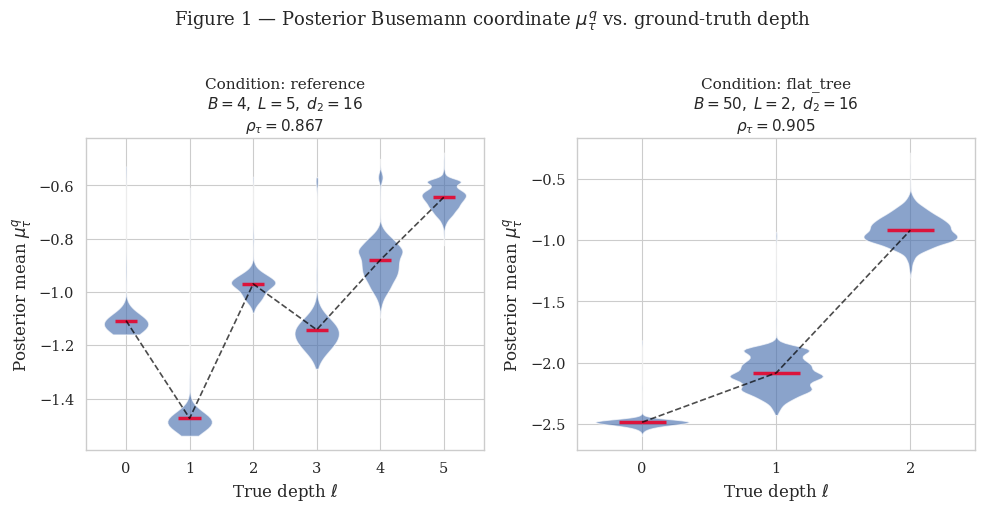

Figure 1 saved → results/fig1_tau_vs_depth.pdf


In [13]:
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)
plt.rcParams['font.family'] = 'serif'

n_conds = len(all_results)
fig, axes = plt.subplots(1, n_conds, figsize=(5*n_conds, 5), sharey=False)
if n_conds == 1: axes = [axes]

for ax, (name, res) in zip(axes, all_results.items()):
    h    = res['hyperbolic']
    tau  = h['latents']['mu_tau']
    deps = h['latents']['depths']
    rho  = h['metrics']['rho_tau']
    cfg  = res['cfg']

    depth_levels = sorted(set(deps.tolist()))
    data_vio     = [tau[deps == d] for d in depth_levels]

    vp = ax.violinplot(data_vio, positions=depth_levels, widths=0.7,
                       showmeans=True, showextrema=False)
    for body in vp['bodies']:
        body.set_facecolor('#4C72B0')
        body.set_alpha(0.65)
    vp['cmeans'].set_color('crimson')
    vp['cmeans'].set_linewidth(2.5)

    # Regression line
    means = [np.mean(tau[deps == d]) for d in depth_levels]
    ax.plot(depth_levels, means, 'k--', linewidth=1.2, alpha=0.7, label='mean trend')

    # Formatting
    ax.set_xlabel('True depth $\\ell$', fontsize=12)
    ax.set_ylabel('Posterior mean $\\mu_\\tau^q$', fontsize=12)
    ax.set_title(
        f'Condition: {name}\n'
        f'$B={cfg["B"]},\\; L={cfg["L"]},\\; d_2={cfg["d2"]}$\n'
        f'$\\rho_\\tau = {rho:.3f}$',
        fontsize=11
    )
    ax.set_xticks(depth_levels)

fig.suptitle('Figure 1 — Posterior Busemann coordinate $\\mu_\\tau^q$ vs.'
             ' ground-truth depth', fontsize=13, y=1.02)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/fig1_tau_vs_depth.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 1 saved → results/fig1_tau_vs_depth.pdf')

### Figure 2 — KL components during training

The total KL is decomposed into three terms (height, fibre, drift). Watching how each evolves tells us what the model is learning:
- **height KL** growing → model is pushing $\mu_\tau^q$ away from the prior mean (good)
- **drift term** growing → model is separating $\mu_b^q$ between prior and posterior (good)
- **val/mean_tau** growing → representations are moving toward larger depth in $\mathbb{H}^d$

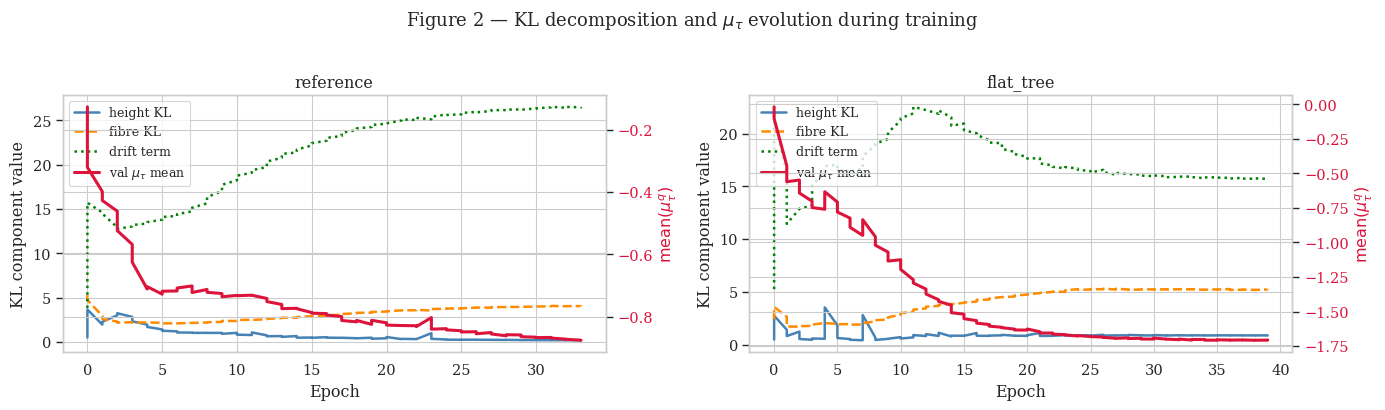

Figure 2 saved → results/fig2_training_dynamics.pdf


In [14]:
def load_csv_log(path):
    rows = []
    with open(path) as f:
        for row in csv.DictReader(f):
            rows.append({k: float(v) for k, v in row.items() if v != ''})
    return rows

fig, axes = plt.subplots(1, n_conds, figsize=(7*n_conds, 4), sharey=False)
if n_conds == 1: axes = [axes]

for ax, (name, _) in zip(axes, all_results.items()):
    log_dir  = f'results/{name}/hyperbolic'
    versions = sorted([d for d in os.listdir(log_dir) if d.startswith('version')])
    if not versions: continue
    csv_path = f'{log_dir}/{versions[-1]}/metrics.csv'
    if not os.path.exists(csv_path): continue

    rows      = [r for r in load_csv_log(csv_path) if 'epoch' in r]
    if not rows: continue

    epochs    = [r['epoch'] for r in rows]
    kl_keys   = [('train/kl_height', 'height KL',  '-',  'steelblue'),
                 ('train/kl_fibre',  'fibre KL',   '--', 'darkorange'),
                 ('train/kl_drift',  'drift term', ':',  'green')]
    ax2 = ax.twinx()

    for key, lbl, sty, col in kl_keys:
        vals = [r.get(key, float('nan')) for r in rows]
        vals = [v for v in vals if not math.isnan(v)]
        if vals:
            ax.plot(epochs[:len(vals)], vals, sty, color=col, linewidth=1.8, label=lbl)

    tau_vals = [r.get('val/mean_tau', float('nan')) for r in rows]
    tau_vals = [v for v in tau_vals if not math.isnan(v)]
    if tau_vals:
        ax2.plot(epochs[:len(tau_vals)], tau_vals, '-', color='crimson',
                 linewidth=2.2, label='val $\\mu_\\tau$ mean')

    ax.set_xlabel('Epoch'); ax.set_ylabel('KL component value')
    ax2.set_ylabel('$\\mathrm{mean}(\\mu_\\tau^q)$', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    ax.set_title(f'{name}')
    l1, n1 = ax.get_legend_handles_labels()
    l2, n2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, n1+n2, fontsize=9, loc='upper left')

fig.suptitle('Figure 2 — KL decomposition and $\\mu_\\tau$ evolution during training',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('results/fig2_training_dynamics.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 2 saved → results/fig2_training_dynamics.pdf')

### Figure 3 — Comparative bar chart

Side-by-side comparison of $\rho_\tau$ (hyperbolic) and $\rho_\mathrm{euc}$ (Euclidean baseline) across all conditions. The negative control (`flat_tree`) should show low $\rho_\tau$ for both, confirming that a high score in `reference` is due to hierarchical structure, not model architecture.

/tmp/ipykernel_5534/2399321176.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cond_names, rotation=20, ha='right')


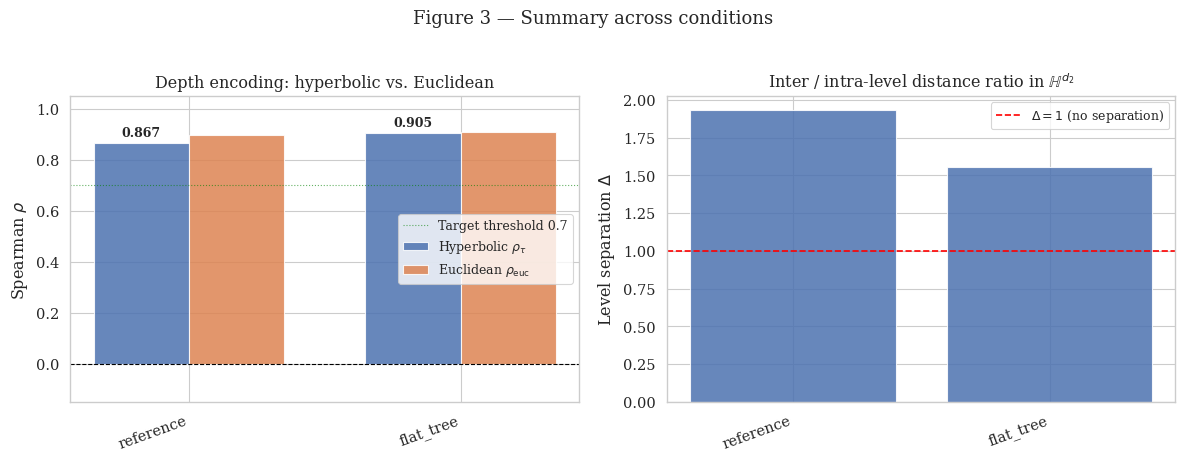

Figure 3 saved → results/fig3_comparison.pdf


In [15]:
cond_names = list(all_results.keys())
rho_hyp    = [all_results[n]['hyperbolic']['metrics']['rho_tau']  for n in cond_names]
rho_euc    = [all_results[n]['euclidean']['metrics']['rho_euc']   for n in cond_names]
deltas     = [all_results[n]['hyperbolic']['metrics']['delta']    for n in cond_names]

x, w = np.arange(len(cond_names)), 0.35
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: Spearman rho comparison
ax = axes[0]
b1 = ax.bar(x-w/2, rho_hyp, w, label='Hyperbolic $\\rho_\\tau$',    color='#4C72B0', alpha=0.85)
b2 = ax.bar(x+w/2, rho_euc, w, label='Euclidean $\\rho_\\mathrm{euc}$', color='#DD8452', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(0.7, color='green', linewidth=0.8, linestyle=':', alpha=0.6, label='Target threshold 0.7')
ax.set_xticks(x); ax.set_xticklabels(cond_names, rotation=20, ha='right')
ax.set_ylabel('Spearman $\\rho$'); ax.set_ylim(-0.15, 1.05)
ax.set_title('Depth encoding: hyperbolic vs. Euclidean')
ax.legend(fontsize=9)
for bar, v in zip(b1, rho_hyp):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.015, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Right: Level separation delta
ax = axes[1]
colors = ['#4C72B0' if d > 1.5 else '#C44E52' for d in deltas]
ax.bar(cond_names, deltas, color=colors, alpha=0.85)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='$\\Delta=1$ (no separation)')
ax.set_xticklabels(cond_names, rotation=20, ha='right')
ax.set_ylabel('Level separation $\\Delta$')
ax.set_title('Inter / intra-level distance ratio in $\\mathbb{H}^{d_2}$')
ax.legend(fontsize=9)

fig.suptitle('Figure 3 — Summary across conditions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('results/fig3_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 3 saved → results/fig3_comparison.pdf')

### Figure 4 — KDE per depth level (reference condition)

Kernel density estimate of $\mu_\tau^q$ for each depth level on the reference condition. Well-separated, non-overlapping peaks indicate that $\tau$ cleanly encodes depth. Overlapping peaks indicate that the model has not learned to use the geometric structure of $\mathbb{H}^d$.

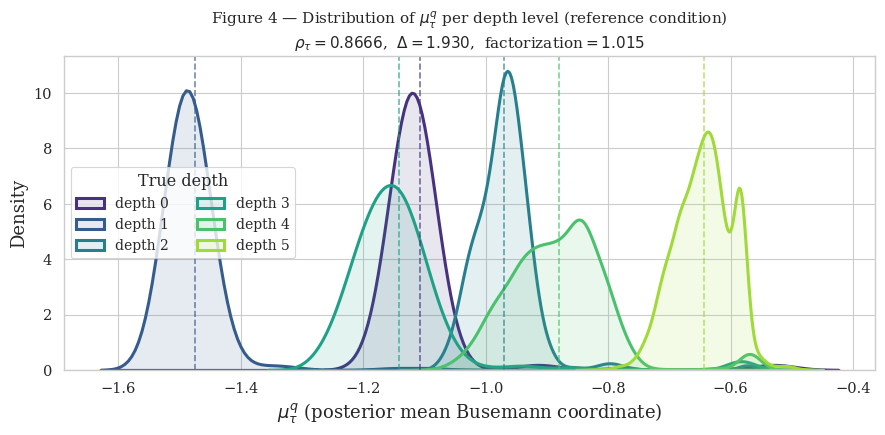

Figure 4 saved → results/fig4_kde.pdf


In [16]:
if 'reference' in all_results:
    h    = all_results['reference']['hyperbolic']
    tau  = h['latents']['mu_tau']
    deps = h['latents']['depths']
    m    = h['metrics']
    L    = all_results['reference']['cfg']['L']

    palette = sns.color_palette('viridis', L+1)
    fig, ax  = plt.subplots(figsize=(9, 4.5))

    for d in range(L+1):
        vals = tau[deps == d]
        if len(vals) > 10:
            sns.kdeplot(vals, ax=ax, label=f'depth {d}',
                        color=palette[d], linewidth=2.2, fill=True, alpha=0.12)
            ax.axvline(np.mean(vals), color=palette[d], linestyle='--',
                       linewidth=1.2, alpha=0.7)

    ax.set_xlabel('$\\mu_\\tau^q$ (posterior mean Busemann coordinate)', fontsize=13)
    ax.set_ylabel('Density', fontsize=13)
    ax.set_title(
        'Figure 4 — Distribution of $\\mu_\\tau^q$ per depth level (reference condition)\n'
        f'$\\rho_\\tau={m["rho_tau"]:.4f}$,  '
        f'$\\Delta={m["delta"]:.3f}$,  '
        f'factorization$={m["factorization"]:.3f}$',
        fontsize=11
    )
    ax.legend(title='True depth', ncol=2, fontsize=10)
    plt.tight_layout()
    plt.savefig('results/fig4_kde.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    print('Figure 4 saved → results/fig4_kde.pdf')

### Figure 5 — UMAP of the hyperbolic latent space

UMAP projection of the latent representations $(\tau_t, e^{-\tau_t} b_t)$, coloured by depth and by $\mu_\tau^q$.

If the model has learned the geometry correctly, we expect:
- Depth levels to cluster separately (left panel)
- $\mu_\tau^q$ to vary smoothly across the UMAP (right panel), confirming that $\tau$ is a globally consistent encoding of depth

Running UMAP on 5000 points...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


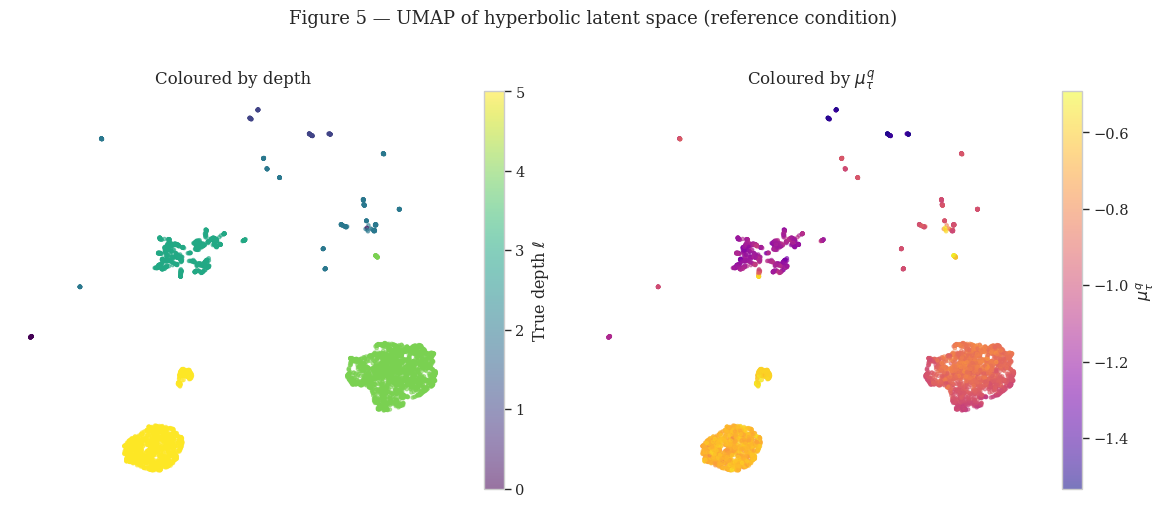

Figure 5 saved → results/fig5_umap.pdf


In [17]:
try:
    import umap.umap_ as umap_lib
    HAS_UMAP = True
except ImportError:
    try:
        import umap as umap_lib
        HAS_UMAP = True
    except ImportError:
        HAS_UMAP = False
        print('umap-learn not available. Skipping Figure 5.')

if HAS_UMAP and 'reference' in all_results:
    h_lat = all_results['reference']['hyperbolic']['latents']
    tau   = h_lat['mu_tau']
    b     = h_lat['mu_b']
    depths = h_lat['depths']

    # Intrinsic coordinates: b_intrinsic = b * exp(-tau) (metric-normalised)
    b_norm = b * np.exp(-tau[:, None])
    feats  = np.concatenate([tau[:, None], b_norm], axis=1)

    # Subsample for speed
    n_sub = min(5000, len(tau))
    idx   = np.random.default_rng(0).choice(len(tau), n_sub, replace=False)

    print(f'Running UMAP on {n_sub} points...')
    reducer = umap_lib.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
    emb     = reducer.fit_transform(feats[idx])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sc1 = axes[0].scatter(emb[:,0], emb[:,1], c=depths[idx],
                          cmap='viridis', s=6, alpha=0.55, rasterized=True)
    plt.colorbar(sc1, ax=axes[0], label='True depth $\\ell$')
    axes[0].set_title('Coloured by depth', fontsize=12)
    axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
    axes[0].axis('off')

    sc2 = axes[1].scatter(emb[:,0], emb[:,1], c=tau[idx],
                          cmap='plasma', s=6, alpha=0.55, rasterized=True)
    plt.colorbar(sc2, ax=axes[1], label='$\\mu_\\tau^q$')
    axes[1].set_title('Coloured by $\\mu_\\tau^q$', fontsize=12)
    axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')
    axes[1].axis('off')

    fig.suptitle('Figure 5 — UMAP of hyperbolic latent space (reference condition)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('results/fig5_umap.pdf', bbox_inches='tight', dpi=150)
    plt.show()
    print('Figure 5 saved → results/fig5_umap.pdf')

---
## Appendix — How to interpret the results for the paper

### If the result is positive ($\rho_\tau > 0.7$, flat tree $< 0.4$)

This is the first demonstration that a sequential world model with a hyperbolic latent space spontaneously encodes hierarchical depth in the Busemann coordinate, without any supervision on the hierarchy. The contribution to report:

1. **Technical**: the $\mathcal{HG}$ distribution enables tractable ELBO training on $\mathbb{H}^d$ at $O(d)$ cost
2. **Empirical**: $\mathbb{H}^d$ acts as a geometric inductive bias that produces interpretable, factorised representations on tree-structured environments

### If the result is negative or ambiguous

This is also valuable. It tells us that the ELBO pressure alone is insufficient to produce geometric factorisation. Possible explanations to investigate:
- The approximation error $\frac{d^2-1}{8}\sigma^2$ is too large (try smaller $d_2$ or larger $\beta$)
- The GRU architecture does not provide enough inductive bias toward depth transitions
- The environment's hierarchical signal is too weak relative to noise

A well-documented negative result with this level of experimental rigour is a contribution.

### Files produced

```
results/
├── summary.json              ← all metrics, all conditions
├── fig1_tau_vs_depth.pdf     ← violin plots per depth level
├── fig2_training_dynamics.pdf← KL decomposition during training
├── fig3_comparison.pdf       ← rho_tau vs rho_euc bar chart
├── fig4_kde.pdf              ← density per depth level
├── fig5_umap.pdf             ← UMAP of latent space
└── {condition}/{model}/      ← raw CSV logs and model checkpoints
```